## Imports & data

In [42]:
# ============================================================================
# Imports & data
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Load datasets
df_new = pd.read_csv("../data/sites/shanta-new-luika/historical.csv")
df_new.columns = df_new.columns.str.lower()
df_old = pd.read_csv("../data/sites/shanta-new-luika/historical_2025_06_24.csv")
df_old.columns = df_old.columns.str.lower()

# Bins (keep your current conventions)
grade_edges  = [0, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 1000]
grade_labels = ["<1.0", "1.0-1.5", "1.5-2.0", "2.0-2.5", "2.5-3.0", "3.0-3.5", ">3.5"]

ultrafines_edges  = [0, 60, 70, 80, 90, 101]
ultrafines_labels = ["<60%", "60-70%", "70-80%", "80-90%", ">90%"]

# For rendering in consistent order
GRADE_CAT = pd.CategoricalDtype(categories=grade_labels, ordered=True)
UF_CAT    = pd.CategoricalDtype(categories=ultrafines_labels, ordered=True)


## Prep → bin → summarise (reusable)

In [43]:
# ============================================================================
# Helper: prep, bin, summarise one dataframe
# ============================================================================
def prep_bin_summarise(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Helper fields (max across tanks)
    df["cn_max_field"] = df[["free_cn_leach_tank_1_ppm", "free_cn_leach_tank_2_ppm"]].max(axis=1)
    df["do_max_field"] = df[["do_leach_tank_1_ppm", "do_leach_tank_2_ppm"]].max(axis=1)

    # Treat zeros as missing for guidance stats
    def nz(x): return x.replace(0, np.nan)
    df["cn_max_field"] = nz(df["cn_max_field"])
    df["do_max_field"] = nz(df["do_max_field"])
    if "recovery_pct" in df.columns:
        df["recovery_pct"] = nz(df["recovery_pct"])

    # Bin
    df["grade_bin"] = pd.cut(df["leach_feed_grade_au_gt_day"], bins=grade_edges,
                             labels=grade_labels, right=False).astype(GRADE_CAT)
    df["ultrafines_bin"] = pd.cut(df["leach_feed_lt_75um_day"], bins=ultrafines_edges,
                                  labels=ultrafines_labels, right=False).astype(UF_CAT)

    df_b = df.dropna(subset=["grade_bin", "ultrafines_bin"]).copy()

    # Summarise
    summary = (
        df_b.groupby(["grade_bin", "ultrafines_bin"], observed=True)
            .agg(
                cn_min=("cn_max_field", "min"),
                cn_max=("cn_max_field", "max"),
                cn_mean=("cn_max_field", "mean"),
                cn_median=("cn_max_field", "median"),
                do_min=("do_max_field", "min"),
                do_max=("do_max_field", "max"),
                do_mean=("do_max_field", "mean"),
                do_median=("do_max_field", "median"),
                recovery_min=("recovery_pct", "min"),
                recovery_max=("recovery_pct", "max"),
                recovery_mean=("recovery_pct", "mean"),
                recovery_median=("recovery_pct", "median"),
                n=("cn_max_field", "count"),
            )
            .reset_index()
    )

    # Reindex to full grid so the heatmaps are rectangular (even if some bins have no data)
    full_index = pd.MultiIndex.from_product([GRADE_CAT.categories, UF_CAT.categories],
                                            names=["grade_bin", "ultrafines_bin"])
    summary = summary.set_index(["grade_bin", "ultrafines_bin"]).reindex(full_index).reset_index()
    return summary


## Compute both summaries, build a diff table

In [44]:
# ============================================================================
# Summarise old & new; build diff with absolute and % deltas
# ============================================================================
s_new = prep_bin_summarise(df_new)
s_old = prep_bin_summarise(df_old)

metrics = ["cn_mean", "do_mean", "recovery_mean"]
aux     = ["cn_min","cn_max","do_min","do_max","recovery_min","recovery_max","n"]

diff = (s_new.merge(s_old, on=["grade_bin","ultrafines_bin"], how="outer",
                    suffixes=("_new","_old")))

# Absolute deltas (new - old) and percent deltas
for m in metrics:
    diff[f"{m}_delta"] = diff[f"{m}_new"] - diff[f"{m}_old"]
    diff[f"{m}_pct"] = (diff[f"{m}_delta"] / diff[f"{m}_old"]).replace([np.inf, -np.inf], np.nan) * 100

# Optional: mask bins with very low support in either dataset (e.g., n < 5)
MIN_N = 5
def _mask_low_support(row, colname):
    if (pd.notna(row["n_new"]) and row["n_new"] < MIN_N) or (pd.notna(row["n_old"]) and row["n_old"] < MIN_N):
        return np.nan
    return row[colname]

for m in [f"{x}_new" for x in metrics] + [f"{x}_old" for x in metrics] + \
         [f"{x}_delta" for x in metrics] + [f"{x}_pct" for x in metrics]:
    diff[m] = diff.apply(_mask_low_support, axis=1, colname=m)

# (Nice to have) rounded view for display
diff_display = diff.copy()
for c in diff_display.columns:
    if any(c.endswith(suf) for suf in ["_new","_old","_delta","_pct"]) and diff_display[c].dtype.kind in "fc":
        diff_display[c] = diff_display[c].round(2)

display(diff_display.head(20))


,grade_bin,ultrafines_bin,cn_min_new,cn_max_new,cn_mean_new,cn_median_new,do_min_new,do_max_new,do_mean_new,do_median_new,...,recovery_max_old,recovery_mean_old,recovery_median_old,n_old,cn_mean_delta,cn_mean_pct,do_mean_delta,do_mean_pct,recovery_mean_delta,recovery_mean_pct
0,1.0-1.5,60-70%,300.0,670.0,463.00,442.5,5.35,21.00,14.21,15.25,...,86.52,82.10,82.60,9.0,-18.11,-3.76,0.00,0.00,0.45,0.55
1,1.0-1.5,70-80%,310.0,690.0,463.33,425.0,6.37,22.00,13.55,10.15,...,88.03,83.95,83.77,18.0,7.81,1.71,-1.02,-7.02,1.11,1.32
2,1.0-1.5,80-90%,575.0,575.0,NaN,575.0,20.27,20.27,NaN,20.27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0-1.5,<60%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0-1.5,>90%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.5-2.0,60-70%,240.0,940.0,513.26,425.0,5.93,21.97,17.65,21.00,...,89.95,84.40,84.32,42.0,-0.95,-0.18,-0.19,-1.06,0.16,0.19
6,1.5-2.0,70-80%,65.0,935.0,393.55,375.0,4.56,22.07,16.06,19.01,...,89.47,86.80,87.30,54.0,-13.83,-3.40,2.02,14.36,0.64,0.73
7,1.5-2.0,80-90%,300.0,565.0,379.29,340.0,8.68,21.32,17.29,19.58,...,89.72,87.13,87.39,6.0,44.29,13.22,0.70,4.20,-0.71,-0.81
8,1.5-2.0,<60%,275.0,825.0,NaN,337.5,7.70,21.93,NaN,21.44,...,85.14,NaN,84.03,4.0,NaN,NaN,NaN,NaN,NaN,NaN
9,1.5-2.0,>90%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Heatmap helper (Old | New | Δ)

In [47]:
# ============================================================================
# Plotting helpers
# ============================================================================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

def _pivot(df, value_col, grade_cat=GRADE_CAT, uf_cat=UF_CAT):
    p = df.pivot(index="grade_bin", columns="ultrafines_bin", values=value_col)
    return p.reindex(index=grade_cat.categories, columns=uf_cat.categories)

def _nice_limit(x, step):
    """Round up to a nice tick step so colourbars look clean."""
    if not np.isfinite(x) or x <= 0:
        return step
    return np.ceil(x / step) * step

def _fmt_for(metric, is_delta=False, integers=False):
    # integers=True is used for CN means & CN deltas in your request
    if integers:
        return ".0f"
    if "recovery" in metric:
        return ".1f"
    if "do_" in metric:
        return ".1f"
    return ".1f"

def heatmaps_old_new_delta(
    diff_df,
    value_base: str,                 
    title: str,
    units: str = "",
    annotate=True,
    cn_integers=False,               
    delta_mode: str = "magnitude",   
    cmap_main="YlGnBu",              
    cmap_mag="YlOrRd",                  
    cmap_div="BrBG",                 
):
    """Render Apr-25 | Sep-25 | Δ with tidy, comparable colour scales."""
    p_old = _pivot(diff_df, f"{value_base}_old")
    p_new = _pivot(diff_df, f"{value_base}_new")
    p_dlt = _pivot(diff_df, f"{value_base}_delta")

    # Apr-25/Sep-25 share a common scale for fair comparison
    vmin = np.nanmin([p_old.values, p_new.values])
    vmax = np.nanmax([p_old.values, p_new.values])

    # Annotation formatting
    integers = cn_integers and value_base.startswith("cn_")
    fmt_main = _fmt_for(value_base, integers=integers)
    fmt_delta = _fmt_for(value_base, is_delta=True, integers=integers)

    # Figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.6), sharex=True, sharey=True)
    fig.suptitle(title, y=1.03, fontsize=14)

    # --- Apr-25 ---
    sns.heatmap(
        p_old, ax=axes[0], cmap=cmap_main, vmin=vmin, vmax=vmax,
        linewidths=0.5, linecolor="white",
        annot=annotate, fmt=fmt_main, cbar=True,
        cbar_kws={"shrink": 0.8, "label": f"{value_base.replace('_',' ')} ({units})".strip()}
    )
    axes[0].set_title("Apr-25")
    axes[0].set_xlabel("Ultrafines bin")
    axes[0].set_ylabel("Grade bin")
    axes[0].invert_yaxis()

    # --- Sep-25 ---
    sns.heatmap(
        p_new, ax=axes[1], cmap=cmap_main, vmin=vmin, vmax=vmax,
        linewidths=0.5, linecolor="white",
        annot=annotate, fmt=fmt_main, cbar=True,
        cbar_kws={"shrink": 0.8, "label": f"{value_base.replace('_',' ')} ({units})".strip()}
    )
    axes[1].set_title("Sep-25")
    axes[1].set_xlabel("Ultrafines bin")
    axes[1].set_ylabel("")

    # --- Δ panel ---
    if delta_mode == "signed":
        # Diverging, centred at 0 (shows direction)
        max_abs = np.nanmax(np.abs(p_dlt.values))
        step = 10 if value_base.startswith("cn_") else (0.5 if value_base.startswith("do_") else 0.2)
        dv = _nice_limit(max_abs, step)
        sns.heatmap(
            p_dlt, ax=axes[2], cmap=cmap_div, center=0, vmin=-dv, vmax=dv,
            linewidths=0.5, linecolor="white",
            annot=annotate, fmt=fmt_delta, cbar=True,
            cbar_kws={"shrink": 0.8, "label": f"Δ new-old ({units or 'pp'})"}
        )
        axes[2].set_title("Δ (New - Old)")
    else:
        # Magnitude: colour encodes |Δ| (0 is best), annotation shows signed Δ
        p_mag = np.abs(p_dlt)
        max_abs = np.nanmax(p_mag.values)
        step = 10 if value_base.startswith("cn_") else (0.5 if value_base.startswith("do_") else 0.2)
        vmax_mag = _nice_limit(max_abs, step)
        hm = sns.heatmap(
            p_mag, ax=axes[2], cmap=cmap_mag, vmin=0, vmax=vmax_mag,
            linewidths=0.5, linecolor="white",
            annot=False, cbar=True,
            cbar_kws={"shrink": 0.8, "label": f"|Δ| ({units or 'pp'})"}
        )
        if annotate:
            for y in range(p_dlt.shape[0]):
                for x in range(p_dlt.shape[1]):
                    val = p_dlt.values[y, x]
                    if np.isnan(val):
                        continue
                    axes[2].text(
                        x + 0.5, y + 0.5,
                        f"{val:{fmt_delta}}",
                        ha="center", va="center", fontsize=10, color="black"
                    )
        axes[2].set_title("|Δ| (colour) with signed Δ labels")

    # Cosmetics
    for ax in axes:
        ax.tick_params(axis="x", rotation=45)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.6)
            spine.set_color("#cccccc")
        ax.grid(False)

    plt.tight_layout()
    plt.show()


## Render the comparisons

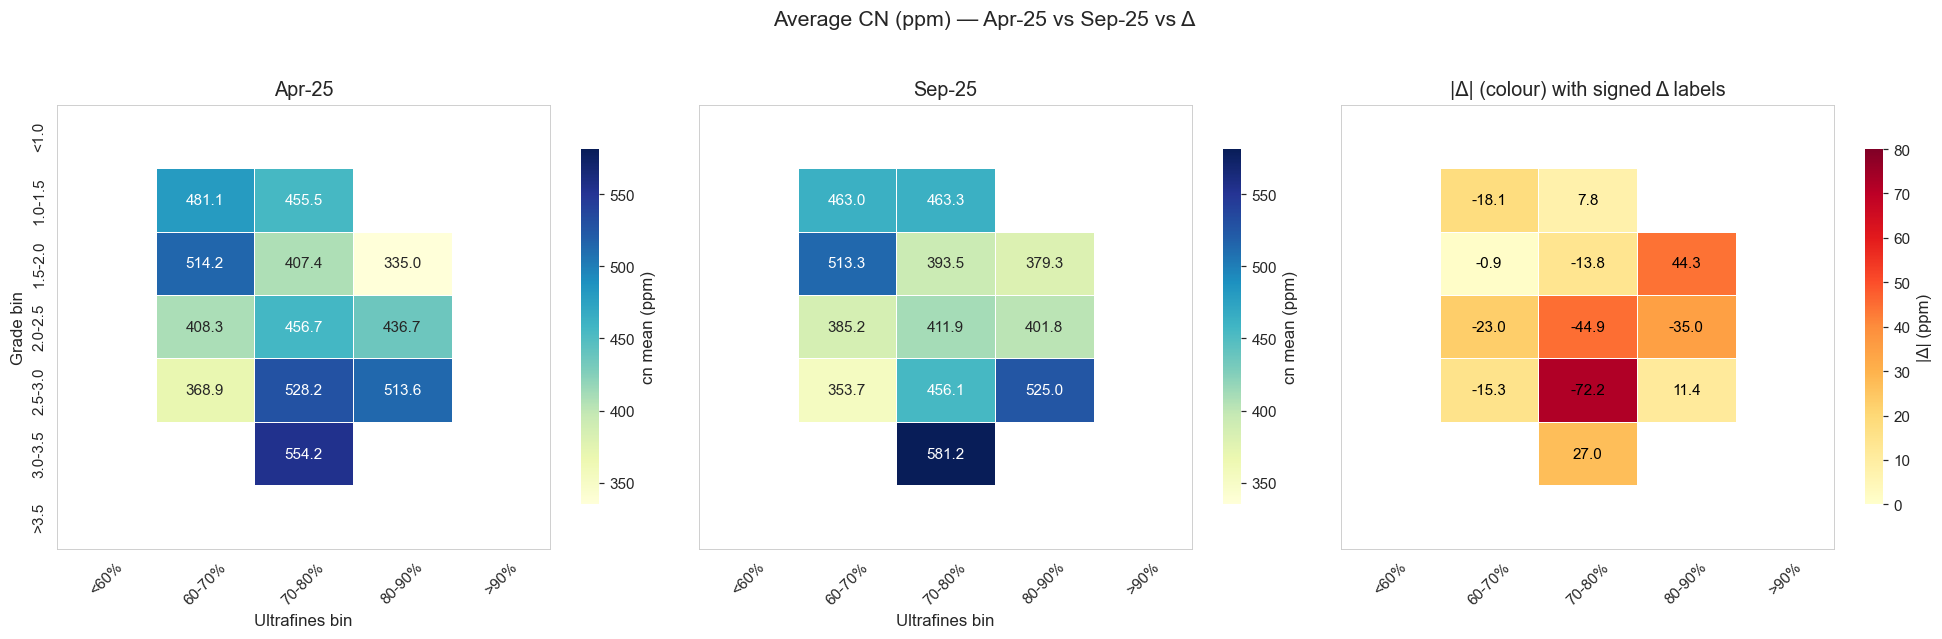

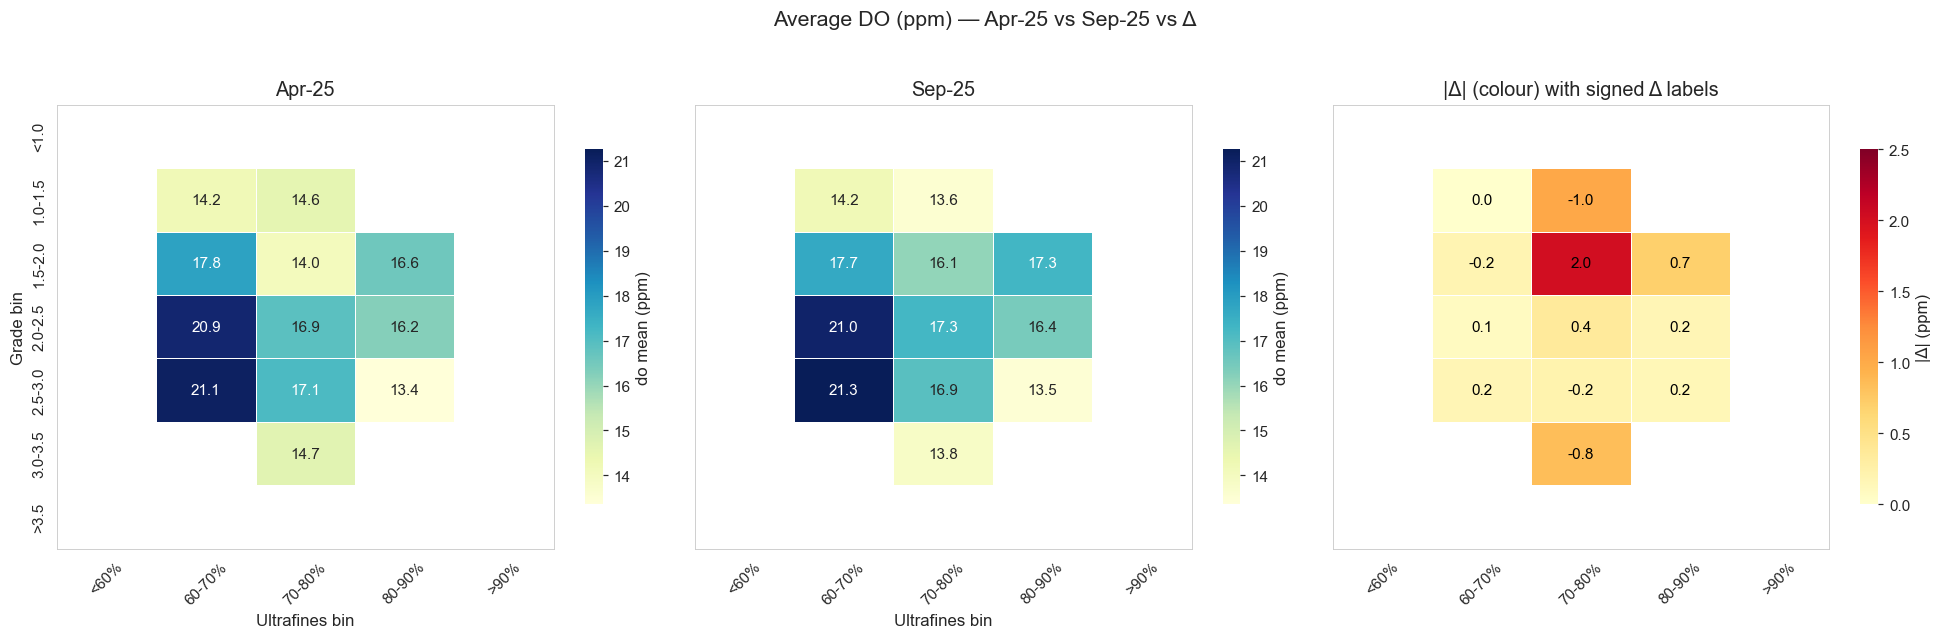

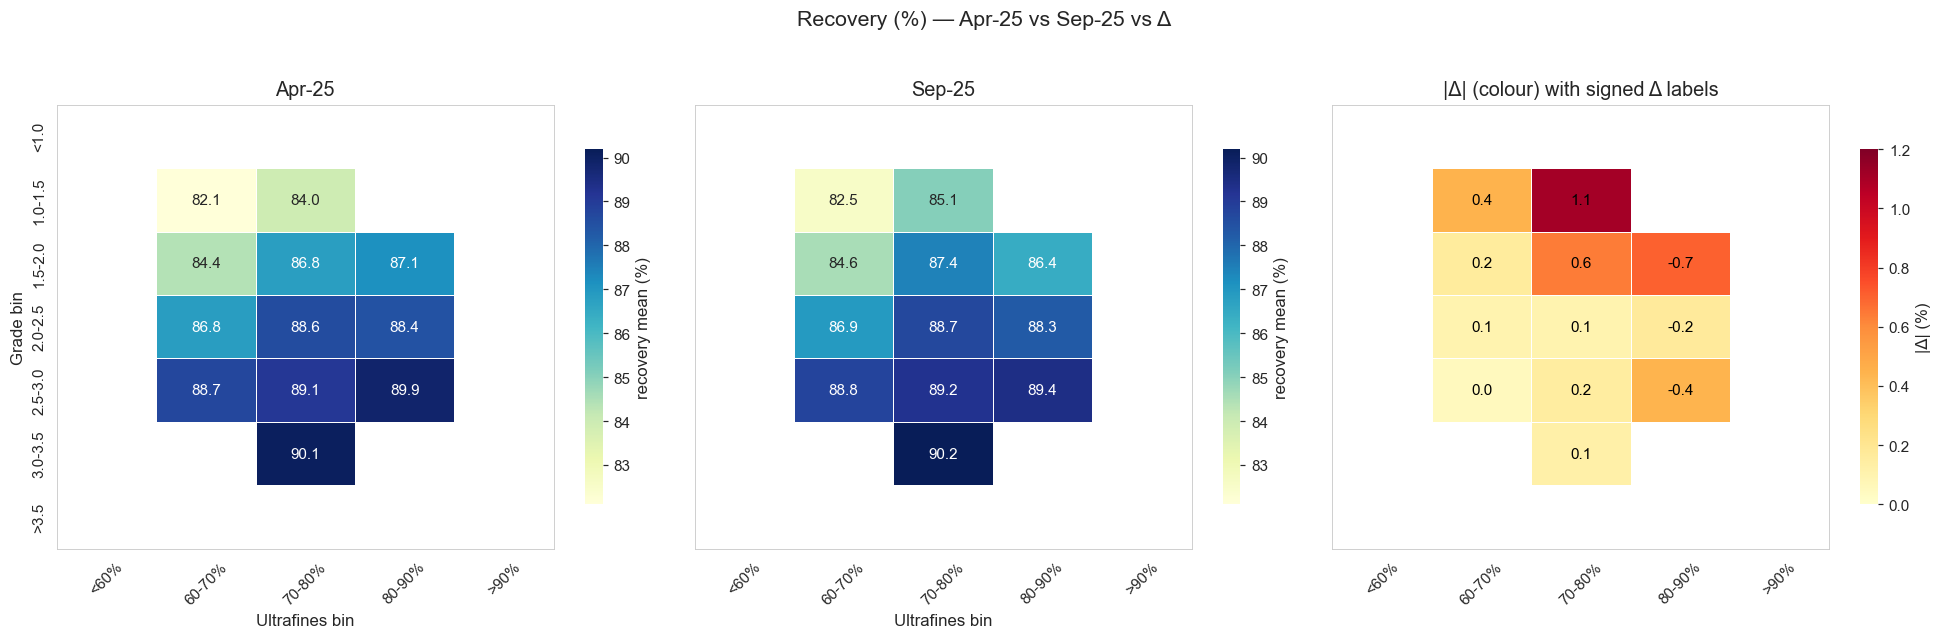

In [48]:
# ============================================================================
# Render: CN, DO, Recovery
# ============================================================================
heatmaps_old_new_delta(diff, "cn_mean",       "Average CN (ppm) - Apr-25 vs Sep-25 vs Δ", units="ppm")
heatmaps_old_new_delta(diff, "do_mean",       "Average DO (ppm) - Apr-25 vs Sep-25 vs Δ", units="ppm")
heatmaps_old_new_delta(diff, "recovery_mean", "Recovery (%) - Apr-25 vs Sep-25 vs Δ",     units="%")


In [37]:
# ============================================================================
# Missing-data check for binning fields (proportion, old vs new)
# Treat NaN and zeros as missing; compare % missing between datasets
# ============================================================================

import numpy as np
import pandas as pd

# Ensure lowercase columns (no-ops if already done)
df_old.columns = df_old.columns.str.lower()
df_new.columns = df_new.columns.str.lower()

# Field names used in binning
GRADE_COL = "leach_feed_grade_au_gt_day"
UF_COL    = "leach_feed_lt_75um_day"
CN1_COL   = "free_cn_leach_tank_1_ppm"
CN2_COL   = "free_cn_leach_tank_2_ppm"
DO1_COL   = "do_leach_tank_1_ppm"
DO2_COL   = "do_leach_tank_2_ppm"

def _prep_cn_do_max(df: pd.DataFrame) -> pd.DataFrame:
    """Return copy with zeros→NaN for CN/DO inputs, then build max fields."""
    d = df.copy()
    for c in [CN1_COL, CN2_COL, DO1_COL, DO2_COL]:
        if c in d:
            d[c] = d[c].where(~((d[c].isna()) | (d[c] == 0)), np.nan)
        else:
            d[c] = np.nan
    d["cn_max_field"] = d[[CN1_COL, CN2_COL]].max(axis=1, skipna=True)
    d["do_max_field"] = d[[DO1_COL, DO2_COL]].max(axis=1, skipna=True)
    return d

def _pct_missing(series: pd.Series, treat_zero_missing: bool = True) -> float:
    """Proportion missing as a fraction (0..1)."""
    if treat_zero_missing:
        m = series.isna() | (series == 0)
    else:
        m = series.isna()
    return float(m.mean()) if len(series) else np.nan

def _missing_summary(df: pd.DataFrame, label: str) -> pd.Series:
    d = _prep_cn_do_max(df)
    out = pd.Series(
        {
            "grade_raw":      _pct_missing(d.get(GRADE_COL, pd.Series(dtype=float)), treat_zero_missing=True),
            "ultrafines_raw": _pct_missing(d.get(UF_COL,    pd.Series(dtype=float)), treat_zero_missing=True),

            # inputs to CN/DO max:
            "cn1_raw":        _pct_missing(d.get(CN1_COL, pd.Series(dtype=float)), treat_zero_missing=True),
            "cn2_raw":        _pct_missing(d.get(CN2_COL, pd.Series(dtype=float)), treat_zero_missing=True),
            "do1_raw":        _pct_missing(d.get(DO1_COL, pd.Series(dtype=float)), treat_zero_missing=True),
            "do2_raw":        _pct_missing(d.get(DO2_COL, pd.Series(dtype=float)), treat_zero_missing=True),

            # derived max fields (missing only when both inputs missing):
            "cn_max_field":   _pct_missing(d["cn_max_field"], treat_zero_missing=False),
            "do_max_field":   _pct_missing(d["do_max_field"], treat_zero_missing=False),
        },
        name=label,
    )
    return out

old_s = _missing_summary(df_old, "old")
new_s = _missing_summary(df_new, "new")

miss_tbl = pd.concat([old_s, new_s], axis=1)
miss_tbl["delta_pp"] = (miss_tbl["new"] - miss_tbl["old"]) * 100.0  # percentage points
miss_tbl = (miss_tbl * 100).round(1)  # convert fractions→% and round
miss_tbl = miss_tbl.rename(columns={"old": "old_%", "new": "new_%", "delta_pp": "Δ pp"})

display(miss_tbl)

# Quick headline on DO fields
def print_do_headline(tbl: pd.DataFrame, threshold_pp: float = 1.0) -> None:
    do_inputs = tbl.loc[["do1_raw", "do2_raw"]]
    do_max    = tbl.loc[["do_max_field"]]
    inc_inputs = (do_inputs["Δ pp"] > threshold_pp).any()
    inc_max    = (do_max["Δ pp"] > threshold_pp).any()

    if inc_inputs or inc_max:
        print(
            f"DO missingness is HIGHER in the updated dataset "
            f"(inputs Δ up to {do_inputs['Δ pp'].max():.1f} pp; "
            f"do_max_field Δ {float(do_max['Δ pp']).__round__(1)} pp)."
        )
    else:
        print("No material increase in DO missingness observed in the updated dataset (by > 1.0 pp).")

print_do_headline(miss_tbl)


,old_%,new_%,Δ pp
grade_raw,0.0,0.0,0.0
ultrafines_raw,0.0,0.0,0.0
cn1_raw,5.1,4.7,-41.9
cn2_raw,0.0,0.6,61.6
do1_raw,41.4,48.9,748.2
do2_raw,36.5,45.0,846.5
cn_max_field,0.0,0.6,61.6
do_max_field,36.5,45.0,846.5


DO missingness is HIGHER in the updated dataset (inputs Δ up to 846.5 pp; do_max_field Δ 846.5 pp).


C:\Users\expg\AppData\Local\Temp\ipykernel_22448\4176550854.py:83: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  f"do_max_field Δ {float(do_max['Δ pp']).__round__(1)} pp)."


## Update Guidance YAML File

In [41]:
from pathlib import Path
import pandas as pd
import numpy as np
import yaml

# ==============================
# Config
# ==============================
G_BASE = Path("../config/sites/shanta-new-luika")              # adjust
D_BASE = Path("../data/sites/shanta-new-luika")              # adjust
P_NEW = D_BASE / "historical.csv"      
P_PREV = G_BASE / "guidance.yaml"       
P_OUT = G_BASE / "guidance_updated.yaml"
P_DIFF = G_BASE / "guidance_update_diff.csv"

GRADE_EDGES  = [0, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 1000]
GRADE_LABELS = ["<1.0", "1.0-1.5", "1.5-2.0", "2.0-2.5", "2.5-3.0", "3.0-3.5", ">3.5"]
UF_EDGES     = [0, 60, 70, 80, 90, 101]
UF_LABELS    = ["<60%", "60-70%", "70-80%", "80-90%", ">90%"]

CN_BOUNDS = (250, 600)
DO_BOUNDS = (6, 21)
RECOVERY_TARGET = 0.88           # 88% recovery
MIN_GOOD_ROWS = 5                # min rows to trust recovery-filtered cohort
GOOD_FRACTION = 0.30             # at least 30% of rows in bin

# ==============================
# Helpers
# ==============================
def get_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def pct_band(series, lo=0.25, hi=0.75, bounds=None):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return (np.nan, np.nan)
    l, h = s.quantile([lo, hi]).tolist()
    if bounds:
        l = max(bounds[0], l); h = min(bounds[1], h)
    if not np.isfinite(l) or l >= h:
        m = s.mean()
        l, h = m*0.95, m*1.05
    return (round(float(l),1), round(float(h),1))

# ==============================
# Load data
# ==============================
df = pd.read_csv(P_NEW)
df.columns = df.columns.str.lower()
prev = yaml.safe_load(Path(P_PREV).read_text(encoding="utf-8"))
prev_rules = {(str(r["grade_bin"]), str(r["ultrafines_bin"])): r for r in prev.get("tagging_rules", [])}

# Required fields (explicit + sensible fallbacks)
grade_col = get_col(df, ["leach_feed_grade_au_gt_day", "grade", "head_grade", "au_feed_gt"])
uf_col    = get_col(df, ["leach_feed_lt_75um_day", "ultrafines_pct", "ultrafines", "fines_lt75um_pct"])
cn1_col   = get_col(df, ["free_cn_leach_tank_1_ppm", "cn_concentration_pl_01", "cn_leach_tank_01"])
cn2_col   = get_col(df, ["free_cn_leach_tank_2_ppm", "cn_concentration_pl_02", "cn_leach_tank_02"])
do1_col   = get_col(df, ["do_leach_tank_1_ppm", "dissolved_oxygen_profile_ppm_leach_tank_01", "do_pl_01"])
do2_col   = get_col(df, ["do_leach_tank_2_ppm", "dissolved_oxygen_profile_ppm_leach_tank_02", "do_pl_02"])
rec_col   = get_col(df, ["recovery_pct", "recovery", "au_recovery_pct"])

assert all([grade_col, uf_col, cn1_col, cn2_col, do1_col, do2_col]), "Missing one or more required columns."

# Canonical dataframe
work = pd.DataFrame({
    "grade": pd.to_numeric(df[grade_col], errors="coerce"),
    "ultrafines": pd.to_numeric(df[uf_col], errors="coerce"),
    "cn1": pd.to_numeric(df[cn1_col], errors="coerce"),
    "cn2": pd.to_numeric(df[cn2_col], errors="coerce"),
    "do1": pd.to_numeric(df[do1_col], errors="coerce"),
    "do2": pd.to_numeric(df[do2_col], errors="coerce"),
})
work["recovery"] = pd.to_numeric(df[rec_col], errors="coerce") if rec_col else np.nan
if rec_col and work["recovery"].max(skipna=True) and work["recovery"].max(skipna=True) > 1.5:
    work["recovery"] = work["recovery"]/100.0

# CN/DO definition: max across tanks; treat zeros as missing
for c in ["cn1","cn2","do1","do2"]:
    work[c] = work[c].replace(0, np.nan)
work["cn"] = work[["cn1","cn2"]].max(axis=1)
work["do"] = work[["do1","do2"]].max(axis=1)

# Ultrafines units: convert fraction→% if needed
uf_max = work["ultrafines"].max(skipna=True)
if pd.notna(uf_max) and uf_max <= 1.5:
    work["ultrafines"] = work["ultrafines"] * 100.0

# Binning
work["grade_bin"] = pd.cut(work["grade"], bins=GRADE_EDGES, labels=GRADE_LABELS, right=False)
work["ultrafines_bin"] = pd.cut(work["ultrafines"], bins=UF_EDGES, labels=UF_LABELS, right=False)

# Compute tagging rules
rules = []
for gb in GRADE_LABELS:
    for uf in UF_LABELS:
        sub = work[(work["grade_bin"]==gb) & (work["ultrafines_bin"]==uf)]
        good = sub[sub["recovery"] >= RECOVERY_TARGET] if "recovery" in sub.columns else sub.iloc[0:0]
        use_good = len(good) >= max(MIN_GOOD_ROWS, int(GOOD_FRACTION*len(sub)))
        cohort = good if use_good else sub

        support = int(cohort["cn"].notna().sum())
        reasons = []
        if use_good:
            reasons.append(f"Used recovery≥{int(RECOVERY_TARGET*100)}% cohort (n={len(good)} of {len(sub)}).")
        else:
            reasons.append(f"Insufficient recovery≥{int(RECOVERY_TARGET*100)}% rows; used all rows in bin (n={len(sub)}).")

        if support > 0:
            cn_min, cn_max = pct_band(cohort["cn"], 0.25, 0.75, CN_BOUNDS)
            do_min, do_max = pct_band(cohort["do"], 0.25, 0.75, DO_BOUNDS)
            reasons.append("25-75th percentile with engineering clamps.")
        else:
            old = prev_rules.get((gb, uf), {})
            cn_min, cn_max = old.get("cn_min", 0), old.get("cn_max", 0)
            do_min, do_max = old.get("do_min", 0), old.get("do_max", 0)
            reasons.append("No CN/DO in this bin; retained previous guidance.")

        rules.append({
            "grade_bin": gb, "ultrafines_bin": uf,
            "cn_min": 0 if pd.isna(cn_min) else float(cn_min) if cn_min is not None else None,
            "cn_max": 0 if pd.isna(cn_max) else float(cn_max) if cn_max is not None else None,
            "do_min": 0 if pd.isna(do_min) else float(do_min) if do_min is not None else None,
            "do_max": 0 if pd.isna(do_max) else float(do_max) if do_max is not None else None,
            "cn_tag_reason": " ".join(reasons),
            "do_tag_reason": " ".join(reasons),
            "support": support,
        })

guidance = {
    "grade_bins": {"edges": GRADE_EDGES, "labels": GRADE_LABELS},
    "ultrafines_bins": {"edges": UF_EDGES, "labels": UF_LABELS},
    "tagging_rules": rules,
}

Path(P_OUT).write_text(yaml.safe_dump(guidance, sort_keys=False, allow_unicode=True), encoding="utf-8")

# Optional: quick diff vs previous guidance
prev_df = pd.DataFrame(prev.get("tagging_rules", []))
curr_df = pd.DataFrame(rules)
cmp = (curr_df.merge(prev_df, on=["grade_bin","ultrafines_bin"], how="left", suffixes=("_new","_old")))
for k in ["cn_min","cn_max","do_min","do_max"]:
    cmp[f"delta_{k}"] = cmp[f"{k}_new"] - cmp[f"{k}_old"]
cmp.to_csv(P_DIFF, index=False)

print("Wrote:")
print(" -", P_OUT)
print(" -", P_DIFF)


Wrote:
 - ..\config\sites\shanta\new_luika\guidance_updated.yaml
 - ..\config\sites\shanta\new_luika\guidance_update_diff.csv
